Read header and print it

In [1]:
from tttrkit.ptuio.reader import TTTRReader
from tttrkit.ptuio.utils import estimate_tcspc_bins
import numpy as np

# reader = TTTRReader(r"C:\Users\dalibor\Data\2026-08-13_Leica-grating\512px_zoom1_Speed400_bidi_1.ptu")
reader = TTTRReader(r"C:\Users\dalibor\Data\2026-08-13_Leica-grating\512px_zoom1_Speed400_bidi_la81.ptu")
# reader = TTTRReader(r"C:\Users\dalibor\Data\2025-07-15_Kolomaznikova_FLIM_Leica\SDshBS_9.ptu")

for key, value in reader.header.tags.items():
    if 'Comment' in key:
        print(f'{key}: {value}')


wrap = reader.header.tags.get("TTResultFormat_WrapAround", 1024)
repetition_rate = reader.header.tags.get("TTResult_SyncRate",40e6)  
tcspc_resolution = reader.header.tags.get("MeasDesc_Resolution",5e-12)
tcspc_bins = estimate_tcspc_bins(reader.header.tags,buffer=10) # if buffer = 0, channel overflow can be expected for high temporal resolution


File_Comment: 


Reconstruct only photon count (i.e., intensity) image

In [2]:
from tttrkit.ptuio.reconstructor import ScanConfig
from tttrkit.ptuio.reconstructor import ImageReconstructor
from tttrkit.ptuio.decoder import T3OverflowCorrector

corrector = T3OverflowCorrector(wraparound=wrap)

cfg = ScanConfig(
    bidirectional=True, 
    frames= 1,
    lines=512, 
    pixels=512, 
    line_accumulations= (8,),
    max_detector=2,
    line_start_marker_delay=9e-6,
    line_stop_marker_delay=-205.290e-6,
    )

reconstructor = ImageReconstructor(
        config=cfg, 
        laser_sync_rate=repetition_rate,
        tcspc_channels= tcspc_bins,
        tcspc_resolution=tcspc_resolution,
        outputs=['photon_count']
        )

reader.reset()

for chunk in reader.iter_chunks():
    corrected_chunk = corrector.correct(chunk)
    reconstructor.update(corrected_chunk)


# chunk = reader.read(1_000_000)
# corrected_chunk = corrector.correct(chunk)
# reconstructor.update(corrected_chunk)

result = reconstructor.finalize()


Reconstruction finished.


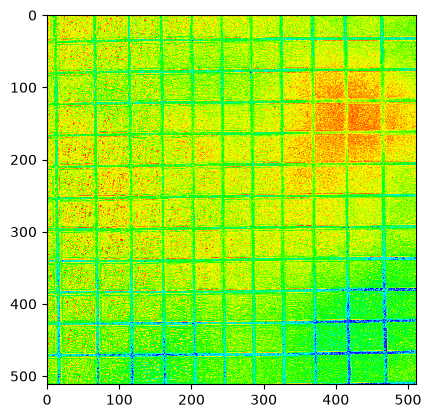

In [3]:
import matplotlib.pyplot as plt
plt.imshow(result.photon_count.values[0,0,:,:,0],cmap='hsv',interpolation='nearest')
plt.show()

Number of starts: 93
Number of stops: 93
Parity:  1
Skipped chunk 1/5
Number of starts: 92
Number of stops: 91
Parity:  1
Skipped chunk 2/5
Number of starts: 84
Number of stops: 84
Parity:  1
Skipped chunk 3/5
Number of starts: 79
Number of stops: 80
Parity:  0
Skipped chunk 4/5
Number of starts: 92
Number of stops: 91
Parity:  0
Skipped chunk 5/5
Durations [nsync]: 69590.0 +/- 3979.1315341985523
Pauses [nsync]: 28038.0 +/- 3986.8938483062375
Duty: 0.7128078010406851
Number of starts: 93
Number of stops: 93
Parity:  1
Skipped chunk 1/5
Number of starts: 92
Number of stops: 91
Parity:  1
Skipped chunk 2/5
Number of starts: 84
Number of stops: 84
Parity:  1
Skipped chunk 3/5
Number of starts: 79
Number of stops: 80
Parity:  0
Skipped chunk 4/5
Number of starts: 92
Number of stops: 91
Parity:  0
Skipped chunk 5/5
Coarse forward/backward pixel offset: -114
Coarse shift [μs]: -197.042


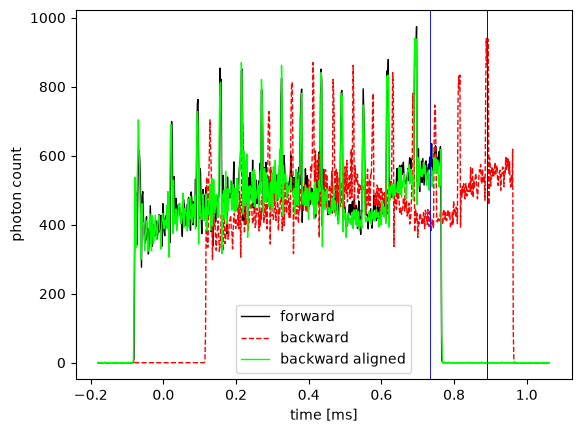

In [4]:
import copy
from tttrkit.ptuio.utils import estimate_bidirectional_prealign


chunks_to_skip = 5

cfg_adjusted = copy.deepcopy(cfg)
# cfg_adjusted.line_start_marker_delay = -100e-6
# cfg_adjusted.line_stop_marker_delay = -91e-6

prealign_result = estimate_bidirectional_prealign(
    reader = reader, 
    cfg=cfg_adjusted,
    laser_sync_rate=repetition_rate,
    chunk_length=500_000,
    skip_chunks=chunks_to_skip,
    )

_,ax = plt.subplots()

ax.plot(1e3 * prealign_result.time_axis.values, prealign_result.forward.values,label = 'forward',color = 'black',lw=1)
ax.plot(1e3 * prealign_result.time_axis.values, prealign_result.backward.values,label='backward', color = 'red', ls = '--',lw=1)
ax.plot(1e3 * prealign_result.time_axis.values, prealign_result.backward_aligned.values,label = 'backward aligned',color = 'lime',lw=1)

for duration in prealign_result.durations_s:
    ax.axvline(1e3 * duration.values,lw=.5,alpha=.25,color='blue')

ax.set_xlabel("time [ms]")
ax.set_ylabel("photon count")
ax.legend()

plt.show()


Number of starts: 19
Number of stops: 18
Parity:  1
Skipped chunk 1/4
Number of starts: 19
Number of stops: 19
Parity:  0
Skipped chunk 2/4
Number of starts: 19
Number of stops: 19
Parity:  1
Skipped chunk 3/4
Number of starts: 18
Number of stops: 18
Parity:  1
Skipped chunk 4/4
1


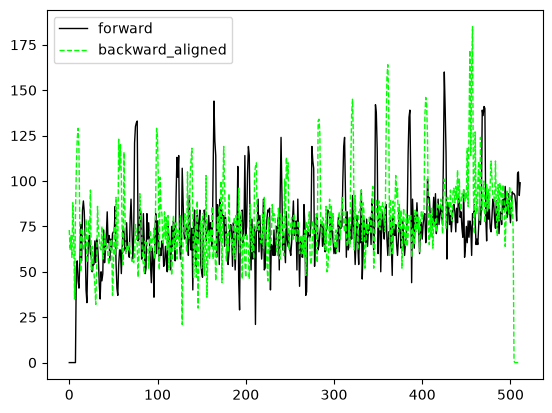

In [64]:
from tttrkit.ptuio.utils import _read_probe_chunk
from tttrkit.ptuio.reconstructor import SegmentReconstructor

chunks_to_skip = 4

cfg_prealigned = copy.deepcopy(cfg_adjusted)
cfg_prealigned.line_start_marker_delay -= 100e-6
# cfg_prealigned.line_stop_marker_delay -= prealign_result.time_shift.values

reader.reset()
corrected_chunk, parity = _read_probe_chunk(
    reader, cfg_prealigned, wrap, 100_000, chunks_to_skip, True
)

print(parity)

seg_recon = SegmentReconstructor(cfg_prealigned,laser_sync_rate=repetition_rate)

ds_aligned = seg_recon.reconstruct(corrected_chunk)

photon_count = ds_aligned.photon_count.values
# forward_aligned = photon_count[0::2].sum(axis=0)
# backward_aligned = photon_count[1::2].sum(axis=0)

n = len(photon_count) // 2
odd_line_sum = photon_count[0:2*n:2].sum(axis=0)
even_line_sum = photon_count[1:2*n:2].sum(axis=0)

if parity == 0:
    forward_aligned = odd_line_sum
    backward_aligned = even_line_sum
else:
    forward_aligned = even_line_sum[::-1]
    backward_aligned = odd_line_sum[::-1]




_,ax = plt.subplots()

ax.plot(forward_aligned,label = 'forward',color = 'black',lw=1)
ax.plot(backward_aligned,label='backward_aligned', color = 'lime', ls = '--',lw=1)
ax.legend()

plt.show()


In [32]:
n

9

In [ ]:
a = np.array([1,2,3,4,5])

n= len(a) /2


a[3::-1]

array([4, 3, 2, 1])

In [25]:
len(photon_count[1::2])

8

## Fine-estimate bi-directional scan phase shift

In [ ]:
from tttrkit.ptuio.utils import estimate_bidirectional_shift

optimization_result = estimate_bidirectional_shift(
        reader=reader,
        config=cfg_prealigned,
        laser_sync_rate=repetition_rate,
        max_shift=3e-6,
        chunk_length=500_000,
        skip_chunks=chunks_to_skip,
        )



Estimating bidirectional phase shift...
Skipped chunk 1/5
Skipped chunk 2/5
Skipped chunk 3/5
Skipped chunk 4/5
Skipped chunk 5/5
Shift -3.00 μs → score 31289.25
Shift -2.40 μs → score 41684.30
Shift -1.80 μs → score 50220.24
Shift -1.20 μs → score 81811.73
Shift -0.60 μs → score 123486.39
Shift 0.00 μs → score 113214.95
Shift 0.60 μs → score 73482.28
Shift 1.20 μs → score 51580.17
Shift 1.80 μs → score 39453.05
Shift 2.40 μs → score 28087.23
Shift 3.00 μs → score 20297.11
Best estimated shift: -0.361 μs


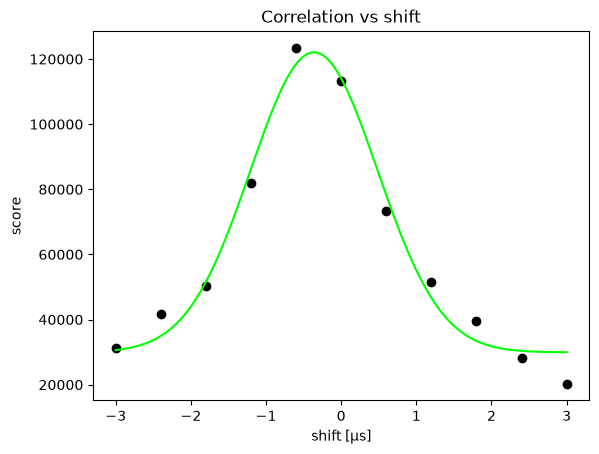

In [ ]:
_, ax = plt.subplots()
ax.plot(
    optimization_result.test_shift.values * 1e6,
    optimization_result.scores.values,
    color='black',
    marker='o',
    ls='',
)

ax.plot(
    optimization_result.fit_shift.values * 1e6,
    optimization_result.fit.values,
    color = 'lime',
    ls='-'
)

ax.set_title('Correlation vs shift')
ax.set_xlabel('shift [μs]')
ax.set_ylabel('score')

plt.show()


## Reconstruct the image with the estimated shift

Reconstruction finished.


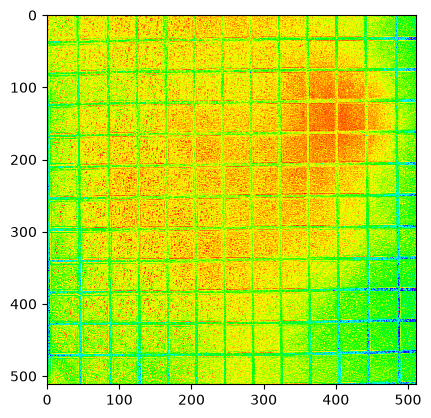

In [ ]:
cfg_aligned = copy.deepcopy(cfg_prealigned)

cfg_aligned.line_start_marker_delay  += optimization_result.best_shift
# cfg_aligned.line_stop_marker_delay += optimization_result.best_shift
cfg_aligned.harmonic_scan = True
cfg_aligned.laser_duty = 0.6

reconstructor = ImageReconstructor(
        config=cfg_aligned, 
        laser_sync_rate=repetition_rate,
        tcspc_channels=tcspc_bins,
        tcspc_resolution=tcspc_resolution,
        outputs=['photon_count'],
        
        )


reader.reset()

for chunk in reader.iter_chunks():
    corrected_chunk = corrector.correct(chunk)
    reconstructor.update(corrected_chunk)



# chunk = reader.read(1_000_000)
# corrected_chunk = corrector.correct(chunk)
# reconstructor.update(corrected_chunk)

result = reconstructor.finalize()
plt.imshow(result.photon_count.values[0,0,:,:,0],cmap='hsv',interpolation='nearest')

plt.show()

Reconstruction finished.


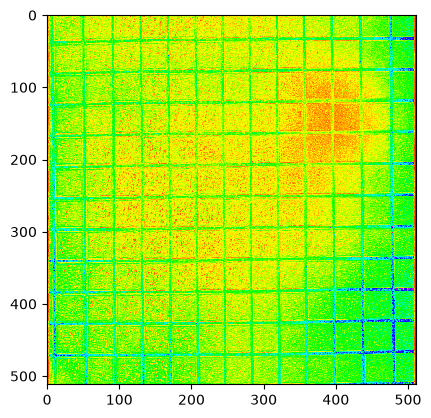

In [ ]:
shift_both = 15e-6

cfg_aligned_shift = copy.deepcopy(cfg_aligned)



cfg_aligned_shift.line_start_marker_delay  += shift_both
cfg_aligned_shift.line_stop_marker_delay -= shift_both

reconstructor = ImageReconstructor(
        config=cfg_aligned_shift, 
        laser_sync_rate=repetition_rate,
        tcspc_channels=tcspc_bins,
        tcspc_resolution=tcspc_resolution,
        outputs=['photon_count'],
        
        )


reader.reset()

for chunk in reader.iter_chunks():
    corrected_chunk = corrector.correct(chunk)
    reconstructor.update(corrected_chunk)



# chunk = reader.read(1_000_000)
# corrected_chunk = corrector.correct(chunk)
# reconstructor.update(corrected_chunk)

result = reconstructor.finalize()
plt.imshow(result.photon_count.values[0,0,:,:,0],cmap='hsv',interpolation='nearest')

plt.show()